<a href="https://colab.research.google.com/github/Varalakshmi-skab/datasciencelearning/blob/main/RandomForestClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

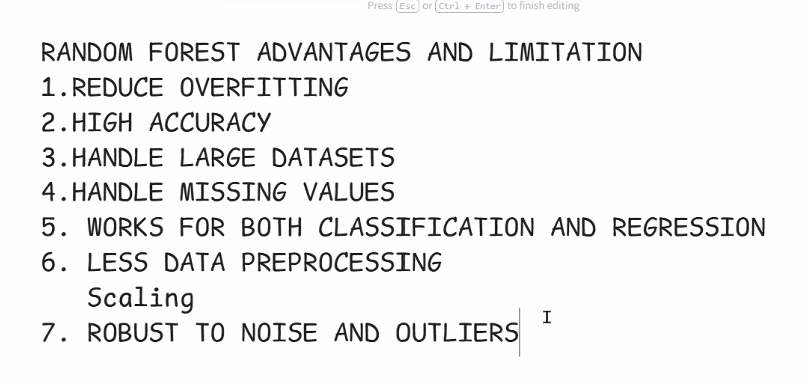

In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [56]:
df=pd.read_csv("/content/drive/MyDrive/Datasets for datascience/rfhouse_classification (1).csv")
df.head()

,Area,Bedrooms,Bathrooms,Parking,Age,Location,House_Type,Nearby_School,Furnished,Crime_Rate,Distance_City,House_Category
0,1460.0,5,1,1,8,Rural,Independent,Yes,Semi,6,12,Budget
1,4372.0,6,4,3,6,Suburban,Villa,Yes,Semi,9,13,Luxury
2,3692.0,5,3,3,8,Suburban,Apartment,No,Semi,2,17,Premium
3,1066.0,3,2,2,17,Suburban,Independent,Yes,Semi,3,17,Budget
4,4044.0,4,1,2,11,Urban,Villa,Yes,Semi,8,36,Premium


In [57]:
df["House_Category"].unique()

array(['Budget', 'Luxury', 'Premium'], dtype=object)

In [58]:
df.shape

(500, 12)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Area            475 non-null    float64
 1   Bedrooms        500 non-null    int64  
 2   Bathrooms       500 non-null    int64  
 3   Parking         500 non-null    int64  
 4   Age             500 non-null    int64  
 5   Location        475 non-null    object 
 6   House_Type      500 non-null    object 
 7   Nearby_School   500 non-null    object 
 8   Furnished       475 non-null    object 
 9   Crime_Rate      500 non-null    int64  
 10  Distance_City   500 non-null    int64  
 11  House_Category  500 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 47.0+ KB


In [60]:
df.isnull().sum()

,0
Area,25
Bedrooms,0
Bathrooms,0
Parking,0
Age,0
Location,25
House_Type,0
Nearby_School,0
Furnished,25
Crime_Rate,0


In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.drop_duplicates(inplace=True)

In [63]:
df.shape

(500, 12)

#missing values:

*  area(num),location(object),furnished(object)




In [64]:
df["Area"]=df["Area"].fillna(df["Area"].mean())
df["Location"]=df["Location"].fillna(df["Location"].mode()[0])
df["Furnished"]=df["Furnished"].fillna(df["Furnished"].mode()[0])


In [65]:
df.isnull().sum()

,0
Area,0
Bedrooms,0
Bathrooms,0
Parking,0
Age,0
Location,0
House_Type,0
Nearby_School,0
Furnished,0
Crime_Rate,0


In [66]:
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Parking', 'Age', 'Location',
       'House_Type', 'Nearby_School', 'Furnished', 'Crime_Rate',
       'Distance_City', 'House_Category'],
      dtype='object')

In [67]:
le=LabelEncoder()
df["Location"]=le.fit_transform(df["Location"])
df["House_Type"]=le.fit_transform(df["House_Type"])
df["Nearby_School"]=le.fit_transform(df["Nearby_School"])
df["Furnished"]=le.fit_transform(df["Furnished"])
df["House_Category"]=le.fit_transform(df["House_Category"])

In [68]:
df

,Area,Bedrooms,Bathrooms,Parking,Age,Location,House_Type,Nearby_School,Furnished,Crime_Rate,Distance_City,House_Category
0,1460.0,5,1,1,8,0,1,1,2,6,12,0
1,4372.0,6,4,3,6,1,2,1,2,9,13,1
2,3692.0,5,3,3,8,1,0,0,2,2,17,2
3,1066.0,3,2,2,17,1,1,1,2,3,17,0
4,4044.0,4,1,2,11,2,2,1,2,8,36,2
...,...,...,...,...,...,...,...,...,...,...,...,...
495,1528.0,4,2,2,4,2,1,1,1,2,12,0
496,733.0,4,3,2,3,1,0,1,2,10,38,0
497,2705.0,5,3,1,17,2,2,1,2,8,13,2
498,4227.0,5,1,0,23,2,0,1,0,7,29,2


In [69]:
X=df.drop("House_Category", axis=1) #independent feature
Y=df["House_Category"] #dependent feature : target

In [70]:
X

,Area,Bedrooms,Bathrooms,Parking,Age,Location,House_Type,Nearby_School,Furnished,Crime_Rate,Distance_City
0,1460.0,5,1,1,8,0,1,1,2,6,12
1,4372.0,6,4,3,6,1,2,1,2,9,13
2,3692.0,5,3,3,8,1,0,0,2,2,17
3,1066.0,3,2,2,17,1,1,1,2,3,17
4,4044.0,4,1,2,11,2,2,1,2,8,36
...,...,...,...,...,...,...,...,...,...,...,...
495,1528.0,4,2,2,4,2,1,1,1,2,12
496,733.0,4,3,2,3,1,0,1,2,10,38
497,2705.0,5,3,1,17,2,2,1,2,8,13
498,4227.0,5,1,0,23,2,0,1,0,7,29


In [71]:
Y

,House_Category
0,0
1,1
2,2
3,0
4,2
...,...
495,0
496,0
497,2
498,2


In [72]:
#splitting the dataset into training and testing data
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.2,random_state=2
)

In [73]:
print(X_train.shape)
print(X_test.shape)

(400, 11)
(100, 11)


In [74]:
from sklearn.ensemble import RandomForestClassifier

In [75]:
#building the model
rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [76]:
#training the model
rf.fit(X_train,Y_train)

RandomForestClassifier(random_state=42)

In [77]:
y_pred=rf.predict(X_test)

In [78]:
y_pred

array([2, 0, 2, 2, 0, 1, 2, 2, 2, 0, 1, 2, 2, 2, 1, 0, 0, 1, 2, 2, 0, 2,
       2, 2, 0, 2, 2, 0, 2, 2, 0, 2, 2, 1, 2, 2, 2, 0, 0, 0, 1, 2, 0, 2,
       2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 2, 2, 0,
       0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 1, 1, 2, 2, 1, 0, 2, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 0, 0, 2, 1, 0, 2, 2, 0])

In [79]:
from sklearn.metrics import accuracy_score

In [80]:
accuracy=accuracy_score(Y_test,y_pred)
print("Accuracy of the model is",accuracy)

Accuracy of the model is 0.84


In [81]:
from sklearn.model_selection import GridSearchCV
paramgrid={
    "n_estimators":[25,50,75,100,125,150,175,200],
    "max_depth":[5,10,15,20,25,30,35,40]
}

In [82]:
grid=GridSearchCV(
    RandomForestClassifier(random_state=42),
    paramgrid,
    scoring="accuracy"
)
grid.fit(X_train,Y_train)

GridSearchCV(estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 10, 15, 20, 25, 30, 35, 40],
                         'n_estimators': [25, 50, 75, 100, 125, 150, 175, 200]},
             scoring='accuracy')

In [83]:
print("best parameters")
print(grid.best_params_)
print("best grid score")
print(grid.best_score_)

best parameters
{'max_depth': 15, 'n_estimators': 200}
best grid score
0.8624999999999998
